In [1]:
import sklearn
import numpy as np

## Load the dataset

In [40]:
from sklearn.datasets import fetch_20newsgroups
#print(fetch_20newsgroups().keys())
# print(fetch_20newsgroups().target_names)
# print(fetch_20newsgroups(subset='train').data[9])
categories = [
    'sci.med',           # medical science articles
    'rec.sport.hockey',  # hockey sports articles
    'comp.graphics',     # computer graphics articles
    'talk.politics.guns' # gun politics articles
]

# load train and test data
train_data = fetch_20newsgroups(subset='train', categories=categories, remove=('headers', 'footers', 'quotes'),random_state=42)
test_data = fetch_20newsgroups(subset='test', categories=categories, remove=('headers', 'footers', 'quotes'),random_state=42)

print("Training samples:", len(train_data.data))
print("Test samples    :", len(test_data.data))
print("Categories      :", train_data.target_names)
print()

# Look at one example
print("Sample text:")
print(train_data.data[0][:300])
print()
print("Label:", train_data.target_names[train_data.target[0]])

Training samples: 2324
Test samples    : 1548
Categories      : ['comp.graphics', 'rec.sport.hockey', 'sci.med', 'talk.politics.guns']

Sample text:



There's a lot of evidence, it just hasn't been adequately gathered and
published in a way that will convince the die-hard melancholic skeptics
who quiver everytime the word 'anecdote' or 'empirical' is used.

For example, Dr. Ivker, who wrote the book "Sinus Survival", always gives,
before any ot

Label: sci.med


## Explore the data before touching any model

In [16]:
# Check class distribution — are classes balanced?
unique, counts = np.unique(train_data.target, return_counts=True)
print("Class distribution in training set:")
for label, count in zip(train_data.target_names, counts):
    bar = '█' * (count // 20)
    print(f"  {label:<25} {count:4d}  {bar}")

print()

Class distribution in training set:
  comp.graphics              584  █████████████████████████████
  rec.sport.hockey           600  ██████████████████████████████
  sci.med                    594  █████████████████████████████
  talk.politics.guns         546  ███████████████████████████



In [ ]:
# print(train_data.data[1][:200])

: Currently, I use a shareware program called Graphics Workshop.
: What kinds of things will Hijaak do that these shareware programs
: will not do?

I also use Graphic Workshop and the only difference


In [17]:
# Check average text length
lengths = [len(text.split()) for text in train_data.data]
print(f"Average words per document : {np.mean(lengths):.0f}")
print(f"Shortest document          : {np.min(lengths)} words")
print(f"Longest document           : {np.max(lengths)} words")

# Look at 3 samples from different categories
for i in range(3):
    print(f"\n--- Sample {i+1} | Category: {train_data.target_names[train_data.target[i]]} ---")
    print(train_data.data[i][:200])

Average words per document : 193
Shortest document          : 0 words
Longest document           : 11251 words

--- Sample 1 | Category: sci.med ---



There's a lot of evidence, it just hasn't been adequately gathered and
published in a way that will convince the die-hard melancholic skeptics
who quiver everytime the word 'anecdote' or 'empirical

--- Sample 2 | Category: comp.graphics ---
: Currently, I use a shareware program called Graphics Workshop.
: What kinds of things will Hijaak do that these shareware programs
: will not do?

I also use Graphic Workshop and the only difference

--- Sample 3 | Category: talk.politics.guns ---

There is a (likely) veto proof majority in the house.  The Senate,
unfortunately, is a different story.  The Lt.Gov. has vowed that the bill will
not be voted on, and he has the power to do it.  In a


In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

# Build the pipeline — two steps chained together
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        stop_words  = 'english',   # remove stopwords
        max_features = 10000,      # keep top 10,000 words by frequency
        ngram_range = (1, 1),      # start with unigrams only
    )),
    ('clf', LogisticRegression(
        max_iter = 1000,           # enough iterations to converge
        random_state = 42,
    )),
])

# Train
pipeline.fit(train_data.data, train_data.target)

# Evaluate
y_pred = pipeline.predict(test_data.data)
accuracy = accuracy_score(test_data.target, y_pred)
print(f"Accuracy: {accuracy:.4f}")  # should be around 0.88-0.90 already

Accuracy: 0.8999


In [29]:
print(classification_report(test_data.target,y_pred,target_names=test_data.target_names))

                    precision    recall  f1-score   support

     comp.graphics       0.91      0.93      0.92       389
  rec.sport.hockey       0.97      0.92      0.94       399
           sci.med       0.83      0.90      0.86       396
talk.politics.guns       0.90      0.85      0.87       364

          accuracy                           0.90      1548
         macro avg       0.90      0.90      0.90      1548
      weighted avg       0.90      0.90      0.90      1548



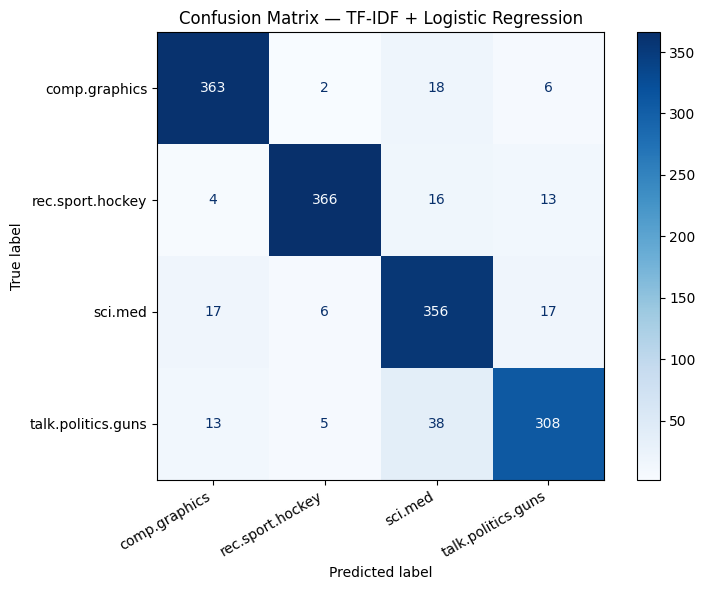


Raw confusion matrix:
[[363   2  18   6]
 [  4 366  16  13]
 [ 17   6 356  17]
 [ 13   5  38 308]]


In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(test_data.target, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels   = test_data.target_names
)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
plt.xticks(rotation=30, ha='right')
plt.title("Confusion Matrix — TF-IDF + Logistic Regression")
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# Each row = actual class. Each column = predicted class.
# The diagonal = correct predictions.
# Off-diagonal = where the model gets confused between categories.
print("\nRaw confusion matrix:")
print(cm)

In [ ]:
# Version 2 — better parameters
pipeline_v2 = Pipeline([
    ('tfidf', TfidfVectorizer(
        stop_words   = 'english',
        max_features = 20000,       # more vocabulary
        ngram_range  = (1, 2),      # unigrams + bigrams
        sublinear_tf = True,        # log-scale term frequency — helps a lot
        min_df       = 2,           # word must appear in at least 2 docs
        max_df       = 0.95,        # ignore words in more than 95% of docs
    )),
    ('clf', LogisticRegression(
        C            = 5.0,         # regularisation — higher C = less regularisation
        max_iter     = 1000,
        solver       = 'lbfgs',
        #multi_class  = 'auto',
        random_state = 42,max_iter=100, verbose=0, warm_start=False, n_jobs=None
    )),
])

pipeline_v2.fit(train_data.data, train_data.target)
y_pred_v2 = pipeline_v2.predict(test_data.data)

accuracy_v2 = accuracy_score(test_data.target, y_pred_v2)
print(f"Version 1 accuracy: {accuracy:.4f}")
print(f"Version 2 accuracy: {accuracy_v2:.4f}")
print(f"Improvement: +{(accuracy_v2 - accuracy)*100:.2f}%")

Version 1 accuracy: 0.8999
Version 2 accuracy: 0.8941
Improvement: +-0.58%


In [33]:
import numpy as np

# Extract components from pipeline
vectorizer = pipeline_v2.named_steps['tfidf']
classifier = pipeline_v2.named_steps['clf']
feature_names = vectorizer.get_feature_names_out()

print("Top 15 most distinctive words per category:\n")
for i, category in enumerate(train_data.target_names):
    # The classifier learned a weight for each feature per class
    # Highest weights = most predictive words for that class
    top_indices = np.argsort(classifier.coef_[i])[-15:]
    top_words   = [feature_names[j] for j in top_indices]
    print(f"{category}:")
    print(f"  {', '.join(top_words)}")
    print()

# Output should look like:
# sci.med:
#   patient, disease, medical, doctor, treatment, surgery, hospital...
# rec.sport.hockey:
#   game, team, hockey, players, season, goal, league, nhl...

Top 15 most distinctive words per category:

comp.graphics:
  looking, thanks, code, algorithm, hi, images, software, ftp, program, 3d, computer, files, file, image, graphics

rec.sport.hockey:
  playoffs, pittsburgh, roger, league, puck, teams, mask, players, nhl, season, play, games, game, team, hockey

sci.med:
  diet, needles, cancer, blood, food, science, patients, effects, treatment, medical, pain, health, disease, msg, doctor

talk.politics.guns:
  gas, nra, com, weapon, batf, police, killed, firearms, people, law, fbi, government, weapons, guns, gun



In [34]:
# Predict on completely new sentences you write yourself
my_texts = [
    "The patient was diagnosed with a severe respiratory infection requiring antibiotics",
    "The team scored three goals in overtime to win the championship",
    "OpenGL and DirectX are used for rendering 3D graphics on GPU hardware",
    "The second amendment protects the right to bear arms in the United States",
    # Test edge cases — what happens with ambiguous text?
    "Python is a great tool for data science and machine learning",  # not in any category
]

predictions   = pipeline_v2.predict(my_texts)
probabilities = pipeline_v2.predict_proba(my_texts)

print(f"{'Text':<60} {'Prediction':<25} {'Confidence'}")
print("-" * 100)
for text, pred, probs in zip(my_texts, predictions, probabilities):
    label      = train_data.target_names[pred]
    confidence = probs.max()
    print(f"{text[:58]:<60} {label:<25} {confidence:.2%}")

Text                                                         Prediction                Confidence
----------------------------------------------------------------------------------------------------
The patient was diagnosed with a severe respiratory infect   sci.med                   80.67%
The team scored three goals in overtime to win the champio   rec.sport.hockey          96.65%
OpenGL and DirectX are used for rendering 3D graphics on G   comp.graphics             96.95%
The second amendment protects the right to bear arms in th   talk.politics.guns        85.14%
Python is a great tool for data science and machine learni   sci.med                   48.74%


In [35]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Combine train and test for cross-validation
all_texts  = train_data.data  + test_data.data
all_labels = list(train_data.target) + list(test_data.target)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# Stratified = each fold has the same class distribution as the full dataset

scores = cross_val_score(
    pipeline_v2,
    all_texts,
    all_labels,
    cv      = cv,
    scoring = 'accuracy',
    n_jobs  = -1,          # use all CPU cores
)

print("Cross-validation accuracy scores:")
for i, score in enumerate(scores, 1):
    bar = '█' * int(score * 40)
    print(f"  Fold {i}: {score:.4f}  {bar}")

print(f"\nMean accuracy : {scores.mean():.4f}")
print(f"Std deviation : {scores.std():.4f}")
print(f"95% CI        : ({scores.mean() - 2*scores.std():.4f}, {scores.mean() + 2*scores.std():.4f})")

Cross-validation accuracy scores:
  Fold 1: 0.9226  ████████████████████████████████████
  Fold 2: 0.9200  ████████████████████████████████████
  Fold 3: 0.9109  ████████████████████████████████████
  Fold 4: 0.9354  █████████████████████████████████████
  Fold 5: 0.9328  █████████████████████████████████████

Mean accuracy : 0.9243
Std deviation : 0.0089
95% CI        : (0.9065, 0.9422)
